# Phase 1 RERUN — Stage B: the compositional question

**Context.** Stage A halted at STOP A (2 A-genes). Stage B was then run **on the protocol owner's explicit instruction** as a measurement:
no stop condition, gene sets and thresholds untouched (`t_age` unchanged; the Stage A classes are read from
`results/tables/rerun_stageA_variance_decomposition.csv`). Write-up: `FINDINGS_STAGEB.md`.

* **B1** per-donor cell-type composition from **all** cells of the raw OneK1K h5ad (Azimuth L2 labels mapped as in the pseudobulk build;
  Doublet/Platelet/Eryth/HSPC excluded and logged; 16 analysis types + `other_PBMC`) → centred log-ratio → `age ~ C(pool) + CLR`.
  The number reported is the fraction of **within-pool** donor-age variance explained, with a within-pool donor-level permutation null.
* **B2** pool-grouped 5-fold CV, 10 repeats, inner pool-grouped alpha selection, HARD RULE 1 asserted in every fold: age from
  (a) composition alone, (b) within-cell-type expression, **all 13,904 genes, unrestricted** kernel ridge — per cell type and all 16
  types jointly, (c) a 2-coefficient recombination of the out-of-fold predictions of (a) and (b). Primary metric: within-pool R²
  (features pool-centred, target pool-centred, held-out predictions re-centred within each held-out pool). Secondary: naive R² on raw age.
  CIs: pool-cluster bootstrap (2,000 draws) plus the spread over the 10 repeats. One within-pool age shuffle per model as a pipeline check.
* **B3** share of the summed within-pool per-gene age variance (Stage A `unique_age`) in A vs MIXED vs I vs OTHER and by identity bin.

In [1]:
import os, sys, warnings
warnings.filterwarnings("ignore")
ROOT = os.path.abspath(os.path.join(os.getcwd(), "..")) if os.path.basename(os.getcwd()) == "notebooks" else os.getcwd()
os.chdir(ROOT); sys.path.insert(0, os.path.join(ROOT, "src"))
os.environ["PYTHONUTF8"] = "1"
from config import *
from rerun_common import RERUN_DIR, RERUN_SEED
import subprocess
def sh(*args):
    """run a src/ script in a subprocess and embed its stdout in the notebook"""
    r = subprocess.run([sys.executable, *args], capture_output=True, text=True, encoding="utf-8", errors="replace")
    print(r.stdout)
    if r.returncode:
        print(r.stderr); raise RuntimeError(f"{args[0]} exited with {r.returncode}")
print("ROOT:", ROOT, "| RERUN_SEED:", RERUN_SEED)

ROOT: <repo> | RERUN_SEED: 20260914


In [2]:
sh("src/rerun_stageB.py")

RERUN STAGE B — the compositional question.  seed = 20260914 | 10 repeats x 5-fold pool-grouped CV, 3-fold inner
[data] log-CPM pseudobulks: 9,623 x 13,904 genes | donors=981 | pools=75 | cell types=16 | every donor in exactly one pool: True
[B0] 981 donors, 75 pools; R2(age ~ pool) = 0.234; within-pool age SD = 14.45 y (total SD 16.51 y). All B2 metrics are on within-pool age unless labelled 'naive'.

[B1] per-donor cell-type composition (all cells of the raw h5ad) -> within-pool age
[filter] cells of the 981 analysis donors                     cells 1,248,980 -> 1,248,980 (removed 0)
[filter] drop non-PBMC / artefact labels ['Doublet', 'Eryth', 'HSPC', 'Platelet']   cells 1,248,980 -> 1,244,937 (removed 4,043)
composition categories: 16 analysis types + 'other_PBMC' = ['ASDC', 'CD4 Proliferating', 'CD8 Proliferating', 'ILC', 'NK_CD56bright', 'Plasmablast', 'cDC1', 'cDC2', 'dnT', 'pDC'] (20,754 cells, 1.67%)
cells per donor used for composition: median 1242 (min 332, max 3492)
mean pr

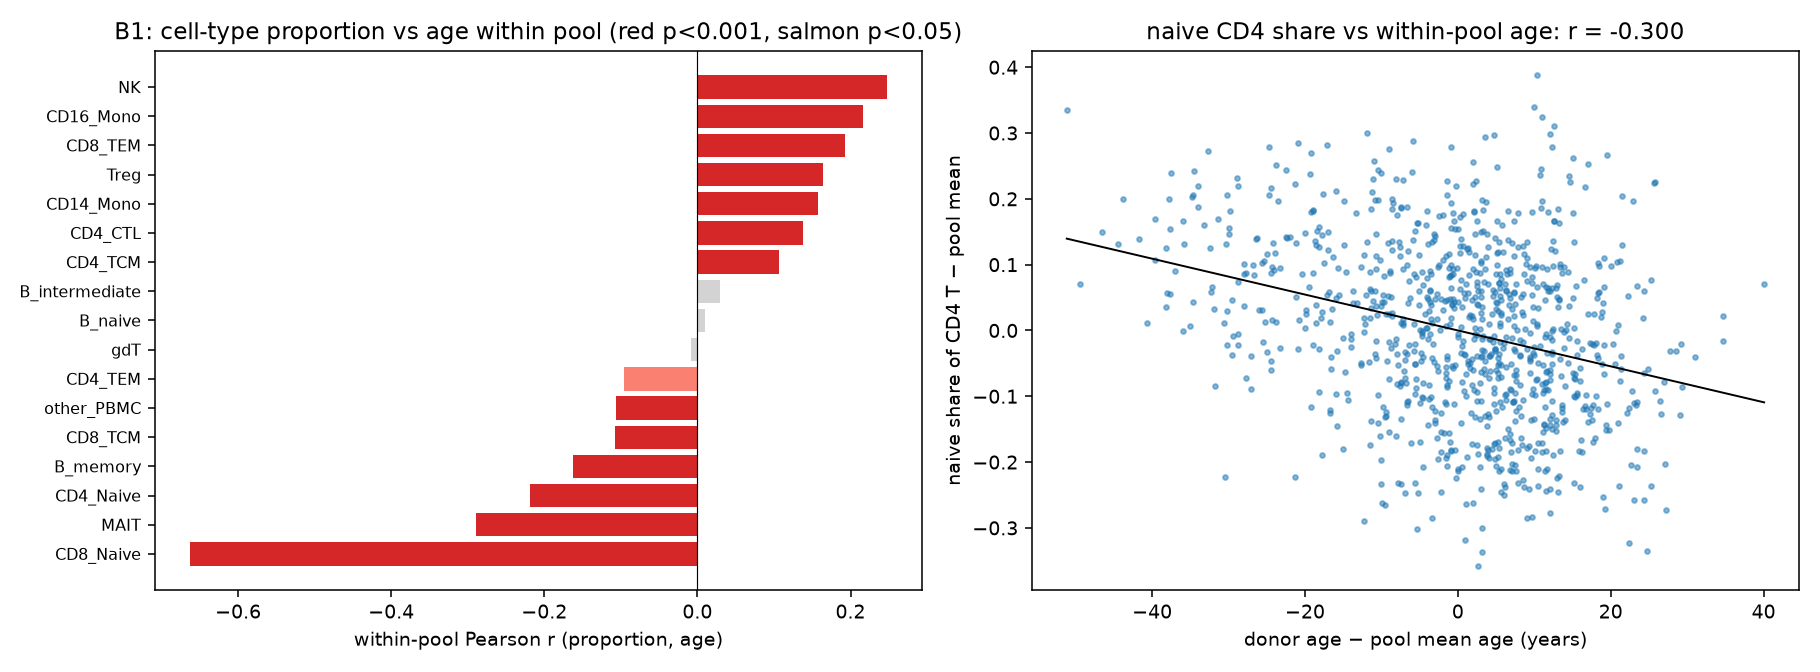

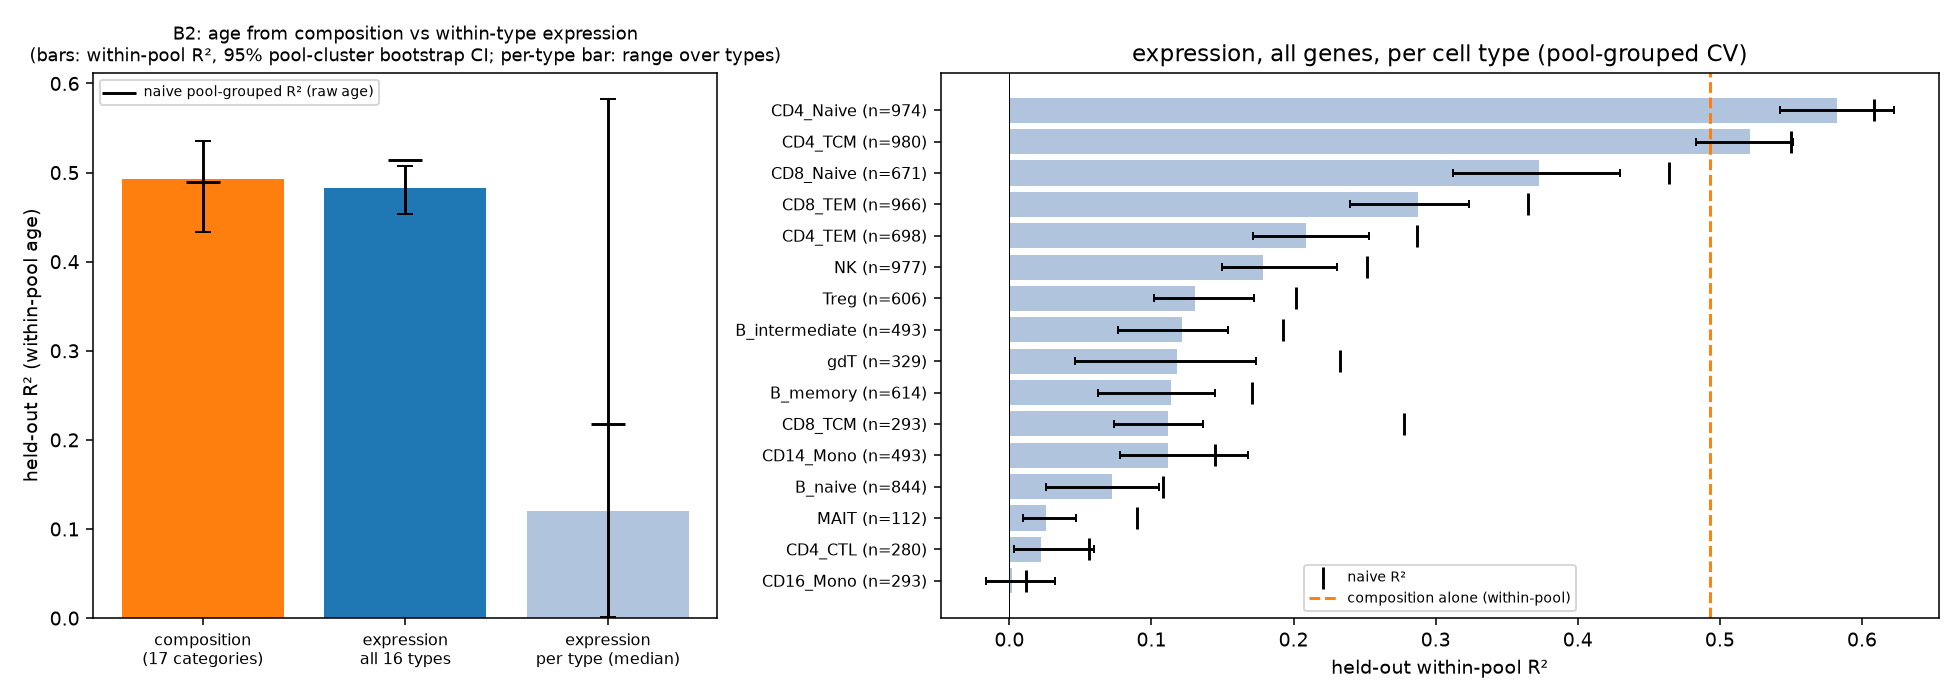

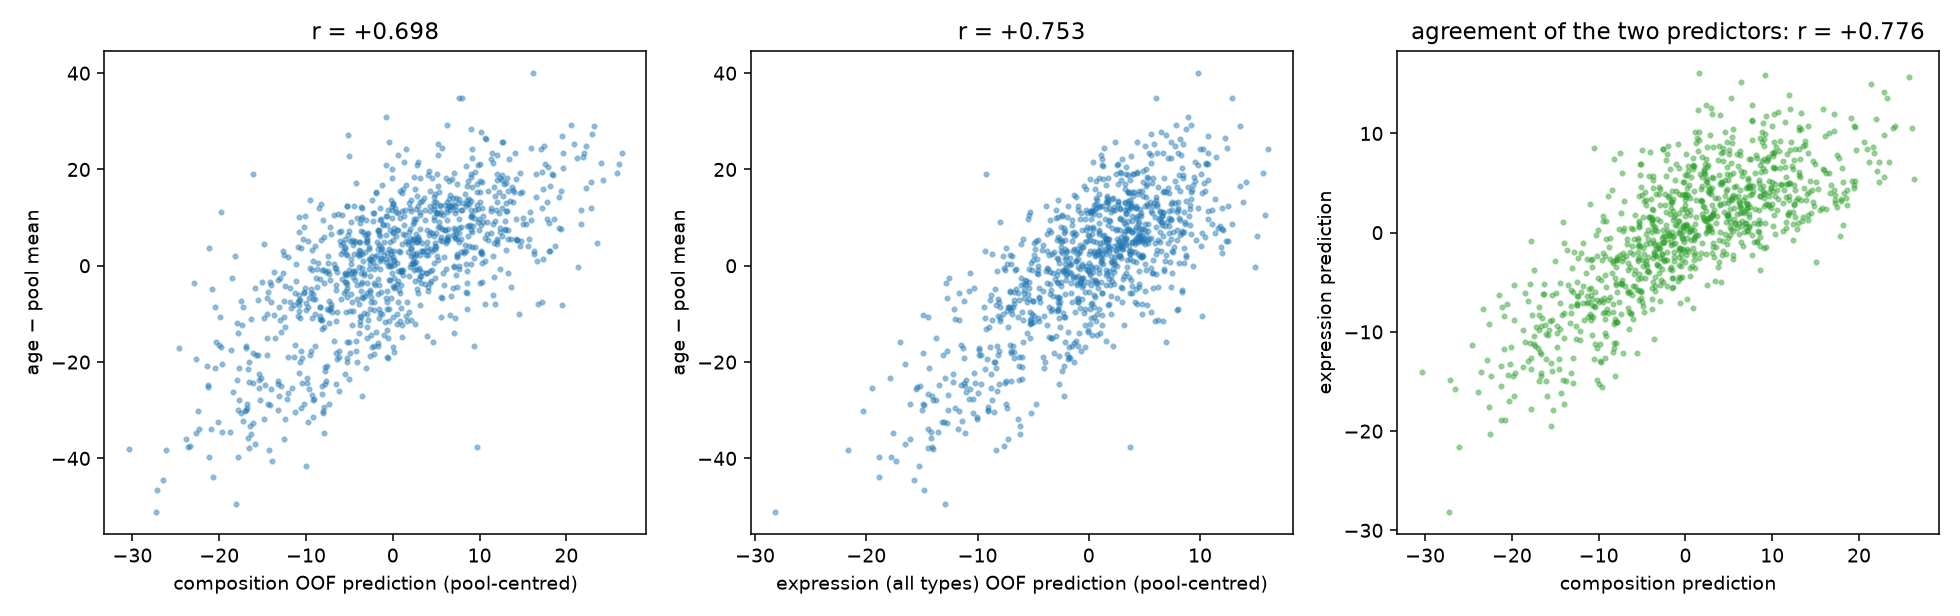

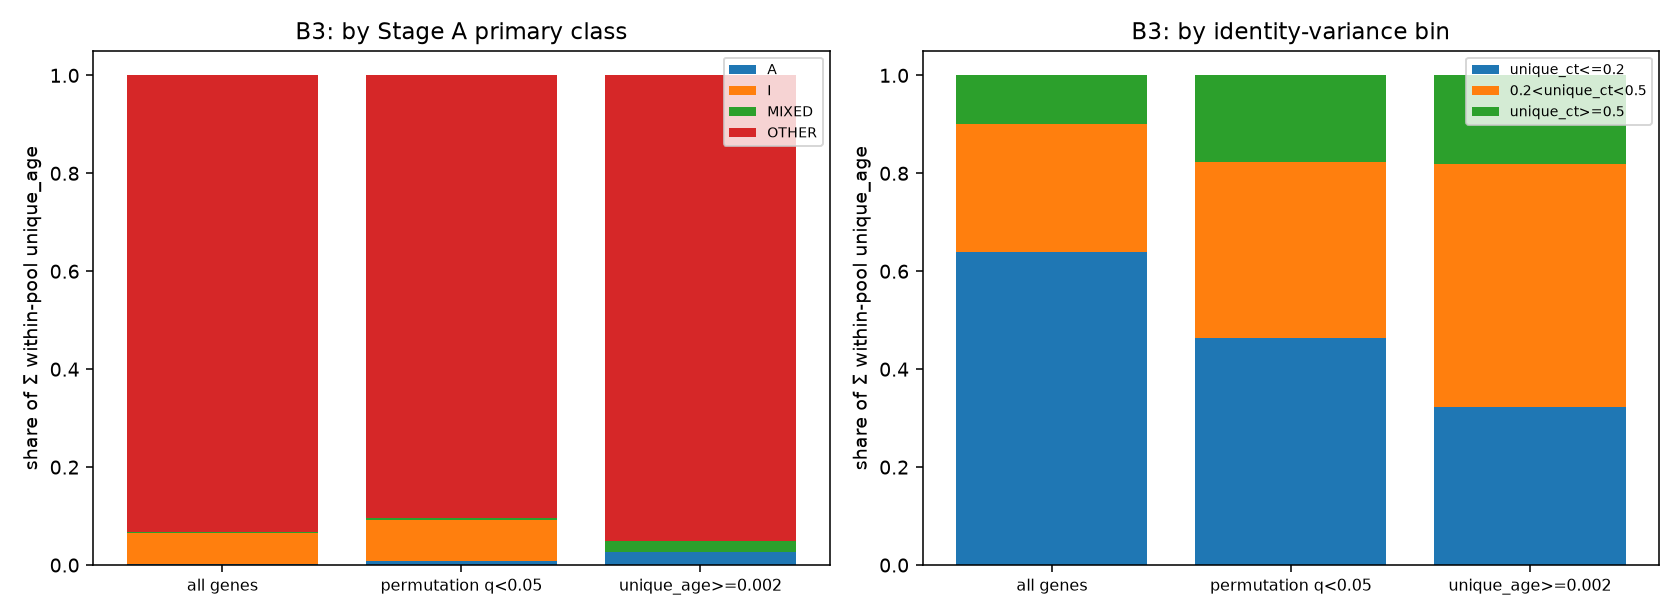

In [3]:
from IPython.display import Image, display
for f in ("rerun_stageB_composition_vs_age.png", "rerun_stageB_cv_composition_vs_expression.png",
          "rerun_stageB_oof_predictions.png", "rerun_stageB_age_signal_by_class.png"):
    display(Image(str(FIG / f)))

In [4]:
import json
s = json.load(open(RERUN_DIR / "stageB_summary.json"))
print("B1  composition explains", f"{s['B1']['frac_within_pool_insample']:.1%}", "of within-pool age variance (in-sample; null", f"{s['B1']['null_increment_mean']/(1-s['B1']['r2_pool']):.1%})")
print("B2  pool-grouped CV within-pool R2: composition", f"{s['B2']['composition_r2_within']:.3f}", s['B2']['composition_ci'],
      "| expression all types", f"{s['B2']['expression_alltype_r2_within']:.3f}", s['B2']['expression_alltype_ci'],
      "| per-type median", f"{s['B2']['expression_per_type_r2_within_median']:.3f}", "| combined 2-df", f"{s['B2']['combined_2df_r2']:.3f}")
print("B3  share of summed within-pool age variance: A", f"{s['B3']['A_share_sum_unique_age']:.1%}", "| MIXED+I", f"{s['B3']['MIXED_plus_I_share']:.1%}",
      "| unique_ct>=0.5", f"{s['B3']['unique_ct_ge_0p5_share']:.1%}")

B1  composition explains 51.5% of within-pool age variance (in-sample; null 1.7%)
B2  pool-grouped CV within-pool R2: composition 0.493 [0.4336323688493762, 0.5356138518483252] | expression all types 0.482 [0.4540146018620064, 0.5075285938722737] | per-type median 0.120 | combined 2-df 0.599
B3  share of summed within-pool age variance: A 0.3% | MIXED+I 6.4% | unique_ct>=0.5 9.9%
